In [3]:
import pandas as pd

# Load the raw feed
df = pd.read_excel('D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/feeds.xlsx')

# Convert timestamp column to datetime (assuming column is 'created_at' or similar)
df['created_at'] = pd.to_datetime(df['created_at'])


# Preview data
print("Data Head:")
print(df.head(10))
print("\nData Info:")
print(df.info())



Data Head:
                 created_at  entry_id    voltage  current  power  energy  \
0 2025-09-24 19:37:26+08:00         1  233.30000    0.000    0.0   0.003   
1 2025-09-24 19:37:48+08:00         2  233.10001    0.495   66.5   0.003   
2 2025-09-24 19:38:10+08:00         3  233.10001    0.495   66.4   0.003   
3 2025-09-24 19:38:31+08:00         4  233.30000    0.501   66.5   0.004   
4 2025-09-24 19:39:18+08:00         5  233.00000    0.498   66.5   0.004   
5 2025-09-24 19:39:44+08:00         6  233.30000    0.497   66.4   0.005   
6 2025-09-24 19:40:31+08:00         7        NaN    0.498   66.4   0.005   
7 2025-09-24 19:40:55+08:00         8        NaN    0.498   66.4   0.005   
8 2025-09-24 19:41:16+08:00         9        NaN    0.498   66.4   0.005   
9 2025-09-24 19:41:37+08:00        10        NaN    0.498   66.4   0.005   

   frequency  power_factor  co2 status latitude  longitude  elevation  \
0       49.9          0.00  NaN    NaN      NaN        NaN        NaN   
1     

In [9]:
# 1️⃣ Drop irrelevant / mostly empty columns
# ---------------------------
df = df.drop(columns=['entry_id', 'latitude','longitude','elevation','status.1','co2'], errors='ignore')

# 2️⃣ Remove outliers based on valid ranges
# ---------------------------
valid_ranges = {
    "voltage": (140, 250),
    "current": (0, 50),
    "power": (0, 5000),
    "energy": (0, 1e6),
    "frequency": (45, 55),
    "power_factor": (0, 1.0)
}
for col, (low, high) in valid_ranges.items():
    if col in df.columns:
        df = df[(df[col].between(low, high)) | (df[col].isna())]

# Standardize column names
df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]

# 2️⃣ Convert datetime and remove timezone
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
if df['created_at'].dt.tz is not None:
    df['created_at'] = df['created_at'].dt.tz_convert('Asia/Kuala_Lumpur').dt.tz_localize(None)
else:
    df['created_at'] = df['created_at'].dt.tz_localize('UTC').dt.tz_convert('Asia/Kuala_Lumpur').dt.tz_localize(None)

df = df.sort_values('created_at').reset_index(drop=True)

# 3️⃣ Enforce numeric
numeric_cols = ['voltage','current','power','energy','frequency','power_factor']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
  
        

In [10]:
# -----------------------------
# Compute time differences
# -----------------------------
df['time_diff_seconds'] = df['created_at'].diff().dt.total_seconds()
df['time_diff_minutes'] = df['time_diff_seconds'] / 60

# -----------------------------
# Define gap thresholds
# -----------------------------
SHORT_GAP_MIN = 2      # Short gap: < 2 minutes, safe to interpolate
LONG_GAP_MIN = 60      # Long gap: >= 60 minutes, treat as missing

# -----------------------------
# Identify gaps
# -----------------------------
df['gap_flag'] = 0
df.loc[df['time_diff_minutes'] > SHORT_GAP_MIN, 'gap_flag'] = 1  # short or long gap
df['long_gap_flag'] = (df['time_diff_minutes'] >= LONG_GAP_MIN).astype(int)

# Optional: keep start/end of gaps
gap_start = df['created_at'].shift(1)
gap_end = df['created_at']

df_gaps = df[df['gap_flag'] == 1].copy()
df_gaps['gap_start'] = gap_start[df_gaps.index]
df_gaps['gap_end'] = gap_end[df_gaps.index]
df_gaps['gap_type'] = df_gaps['time_diff_minutes'].apply(
    lambda x: 'Short Gap (<2m)' if x < LONG_GAP_MIN else 'Long Gap (>60m)'
)

# -----------------------------
# Preserve original numeric data
# -----------------------------
numeric_cols = ['voltage','current','power','energy','frequency','power_factor']
df_before = df[numeric_cols].copy()

# -----------------------------
# Interpolation for short gaps only
# -----------------------------
for col in numeric_cols:
    # Linear interpolation within valid (non-long-gap) regions
    df[col] = df[col].interpolate(method='linear', limit_area='inside')
    
# Mark rows affected by interpolation
interpolated_mask = (df[numeric_cols] != df_before).any(axis=1)

# -----------------------------
# Fill long gaps with zeros or leave NaN (optional)
# -----------------------------
for col in numeric_cols:
    df.loc[df['long_gap_flag'] == 1, col] = 0

# -----------------------------
# Mark flags for later use
# -----------------------------
df['is_missing'] = df['long_gap_flag']
df['was_interpolated'] = interpolated_mask.astype(int)

# -----------------------------
# Show only rows that were interpolated
# -----------------------------
df_interpolated = df[df['was_interpolated'] == 1].copy()

print(f"Total interpolated rows: {len(df_interpolated)}")
print(df_interpolated[['created_at'] + numeric_cols + ['was_interpolated', 'is_missing']])

# -----------------------------
# correct status column
# -----------------------------

df['status'] = np.where((df['voltage'].isna()) | (df['voltage']==0), 0, 1)

Total interpolated rows: 89
              created_at     voltage  current  power  energy  frequency  \
6    2025-09-25 03:40:31  233.322727    0.498   66.4   0.005       49.9   
7    2025-09-25 03:40:55  233.345455    0.498   66.4   0.005       49.9   
8    2025-09-25 03:41:16  233.368182    0.498   66.4   0.005       49.9   
9    2025-09-25 03:41:37  233.390909    0.498   66.4   0.005       49.9   
10   2025-09-25 03:41:59  233.413636    0.498   66.4   0.005       49.9   
...                  ...         ...      ...    ...     ...        ...   
1916 2025-10-09 01:04:40  236.632258    0.000    0.0   0.292       50.0   
1917 2025-10-09 01:05:02  236.654839    0.000    0.0   0.292       50.0   
1918 2025-10-09 01:05:23  236.677419    0.000    0.0   0.292       50.0   
2011 2025-10-09 01:38:20  236.800005    0.239   25.1   0.302       50.0   
5756 2025-10-13 02:35:06  233.350010    0.444   81.4   1.315       49.9   

      power_factor  was_interpolated  is_missing  
6             0.57  

In [11]:
df = df.sort_values('created_at').reset_index(drop=True)

# --- IMPROVED: Handle missing data in energy difference ---
energy_values = df['energy'].values
energy_diffs = np.zeros(len(energy_values))
        
# Find the last valid energy reading for each row
last_valid_energy = energy_values[0]
        
for i in range(1, len(energy_values)):
    current_energy = energy_values[i]
            
    # If current energy is 0 (missing data), carry forward the last valid
    if current_energy == 0:
        energy_diffs[i] = 0
    # If we have a valid energy reading, calculate diff from last valid
    elif current_energy > 0:
        if last_valid_energy > 0:  # Only calculate diff if we had a previous valid reading
            energy_diffs[i] = current_energy - last_valid_energy
            last_valid_energy = current_energy
df['energy_diff'] = energy_diffs

# --- SIMPLE DEFAULT: Trust energy meter ---
df['energy_increment_kwh'] = np.maximum(df['energy_diff'], 0)

# --- SAFETY NET: Detect sensor resets (rare case) ---
time_energy = (df['power'] * (df['time_diff_minutes'] / 60)) / 1000
sensor_reset = df['energy_diff'] < -0.1  # Large negative = reset
        
# Only override if sensor reset detected
df['energy_increment_kwh'] = np.where(
    sensor_reset,
    np.maximum(time_energy, 0),           # Use power-based for resets
    df['energy_increment_kwh']            # Otherwise keep simple approach
)

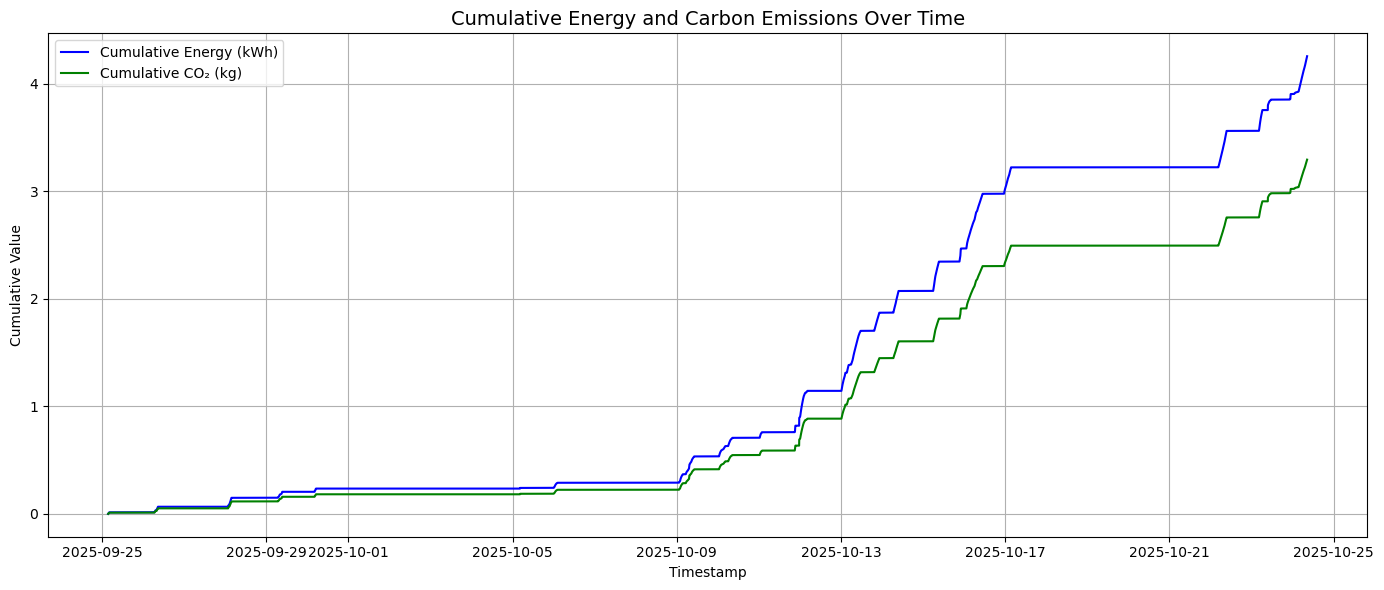

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure timestamp formatting
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at').reset_index(drop=True)

# Select correct energy increment column
# Replace with your actual column name if different
energy_col = 'energy_increment_kwh'

# Calculate cumulative energy
df['cumulative_energy_kwh'] = df[energy_col].cumsum()

# Malaysia grid emission factor
EMISSION_FACTOR = 0.774  # kgCO₂ per kWh

# Calculate cumulative carbon emissions
df['cumulative_carbon'] = df['cumulative_energy_kwh'] * EMISSION_FACTOR

# Plot cumulative curves
plt.figure(figsize=(14,6))

plt.plot(df['created_at'], df['cumulative_energy_kwh'],
         label="Cumulative Energy (kWh)", color='blue')

plt.plot(df['created_at'], df['cumulative_carbon'],
         label="Cumulative CO₂ (kg)", color='green')

plt.title("Cumulative Energy and Carbon Emissions Over Time", fontsize=14)
plt.xlabel("Timestamp")
plt.ylabel("Cumulative Value")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure timestamp is datetime & sorted
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at').reset_index(drop=True)

# Calculate time differences (minutes)
df['gap_minutes'] = df['created_at'].diff().dt.total_seconds() / 60
            
# Identify long gaps > 60 minutes
long_gaps = df[df['gap_minutes'] > 60]

print("Detected long gaps:")
print(long_gaps[['created_at', 'gap_minutes']])


Detected long gaps:
               created_at  gap_minutes
57    2025-09-26 06:41:21  1578.066667
389   2025-09-28 01:47:39  2461.066667
720   2025-09-29 06:54:08  1627.916667
1139  2025-09-30 04:17:01  1132.916667
1281  2025-10-05 04:23:18  7154.600000
1341  2025-10-06 00:02:00  1157.783333
1862  2025-10-09 00:34:29  4166.933333
2342  2025-10-09 05:15:52   100.433333
3190  2025-10-10 00:38:59   860.400000
3827  2025-10-10 06:03:40    96.950000
4226  2025-10-11 00:22:02   950.800000
4486  2025-10-11 20:58:28  1144.300000
4557  2025-10-11 23:31:45   127.916667
5370  2025-10-13 00:15:27  1189.883333
7104  2025-10-13 19:25:50   478.800000
7716  2025-10-14 06:37:24   445.816667
8221  2025-10-15 05:51:05  1213.150000
8790  2025-10-15 21:15:08   720.983333
8943  2025-10-16 01:17:27   188.266667
10467 2025-10-16 23:17:22   751.950000
11152 2025-10-22 04:31:22  7266.750000
11963 2025-10-23 04:17:05  1134.050000
12274 2025-10-23 09:28:38   189.266667
12598 2025-10-23 22:09:04   644.850000
12754

In [16]:
import pandas as pd

# Load the raw feed
df = pd.read_excel('D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ML_READY_DATASET.xlsx')

# Convert timestamp column to datetime (assuming column is 'created_at' or similar)
df['created_at'] = pd.to_datetime(df['created_at'])



Dropping highly correlated features: ['current']
Linear Regression (Reduced + Engineered) -> MAE:0.000951, RMSE:0.002113, R²:0.561163


D:\Users\Rania\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:29:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost High-Energy Classification -> Accuracy:0.9169, Precision:0.7363, Recall:0.7882, F1:0.7614, ROC AUC:0.9445
Confusion Matrix:
 [[793  48]
 [ 36 134]]


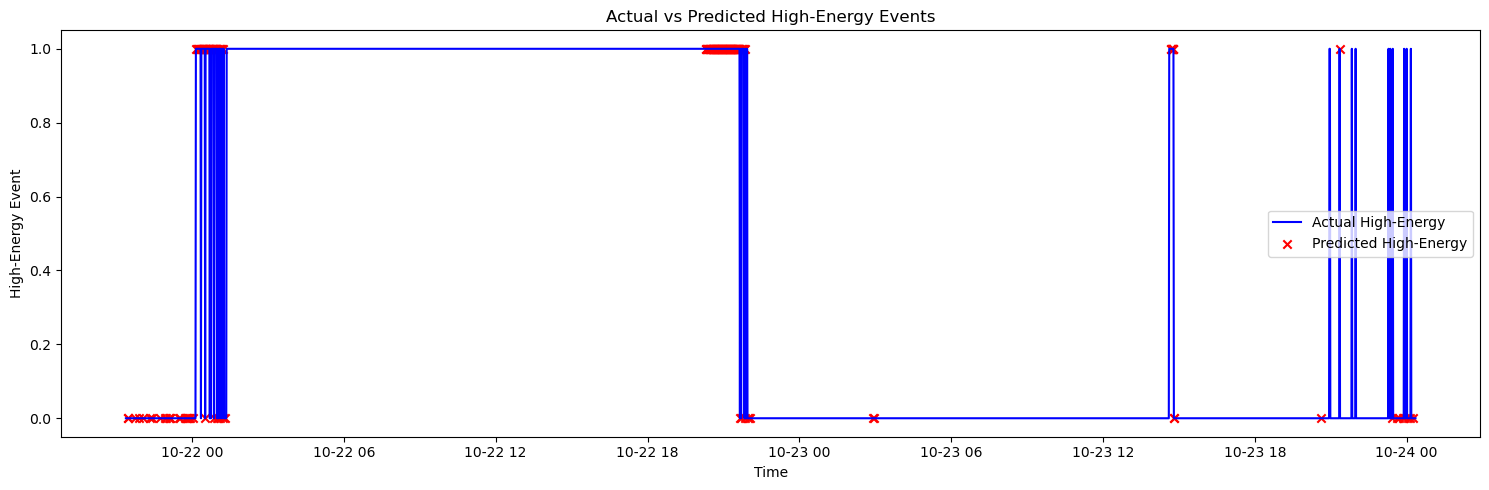

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, precision_recall_curve
)
from sklearn.linear_model import LinearRegression
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# ============================================================
# 1️⃣ Load and preprocess dataset
# ============================================================
df = pd.read_excel(
    'D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ML_READY_DATASET.xlsx'
)
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at').reset_index(drop=True)

# Handle missing or gap flags
df['energy_increment_fixed'] = df['energy_increment_kwh'].copy()
df.loc[df['gap_flag'] == 1, 'energy_increment_fixed'] = 0

# ============================================================
# 2️⃣ Define target (5-min future energy)
# ============================================================
horizon = 5
df['target_future_sum'] = (
    df['energy_increment_fixed']
    .rolling(window=horizon)
    .sum()
    .shift(-horizon)
)
df = df.dropna(subset=['target_future_sum']).reset_index(drop=True)

# ============================================================
# 3️⃣ Add 5-min aligned lag features
# ============================================================
lag_cols = ['energy_increment_fixed','power_factor']
for col in lag_cols:
    df[f'{col}_lag1_5min'] = df[col].shift(horizon)
    df[f'{col}_lag2_5min'] = df[col].shift(horizon*2)

# Drop rows with NaN after lag creation
df = df.dropna().reset_index(drop=True)

# ============================================================
# 4️⃣ Select features
# ============================================================
selected_features = [
    'power','current','voltage','power_factor',
    'power_lag5','power_lag10',
    'energy_increment_kwh_lag1','energy_increment_kwh_lag2','energy_increment_kwh_lag3',
    'energy_increment_kwh_lag5','energy_increment_kwh_lag10',
    'power_rolling_std_3','power_rolling_std_5','power_rolling_std_10',
    'energy_increment_kwh_rolling_mean_3','energy_increment_kwh_rolling_std_3',
    'energy_increment_kwh_rolling_mean_5','energy_increment_kwh_rolling_std_5',
    'energy_increment_kwh_rolling_mean_10','energy_increment_kwh_rolling_std_10',
    'hour_sin','hour_cos','day_of_week_sin','day_of_week_cos','is_weekend',
    'time_diff_min','gap_flag','delta_power','delta_voltage','delta_energy'
]

# Include lag features
lag_features = [f'{col}_lag1_5min' for col in lag_cols] + [f'{col}_lag2_5min' for col in lag_cols]
selected_features += lag_features

X = df[selected_features].fillna(0)
y_reg = df['target_future_sum']

# ============================================================
# 5️⃣ Feature Engineering
# ============================================================
# Interaction feature
X['power_current'] = X['power'] * X['current']

# ============================================================
# 6️⃣ Scale numeric features
# ============================================================
numeric_cols = X.select_dtypes(include=['float64','int64']).columns
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# ============================================================
# 7️⃣ Drop highly correlated features
# ============================================================
threshold = 0.9
corr_matrix = X_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
print("Dropping highly correlated features:", to_drop)
X_reduced = X_scaled.drop(columns=to_drop)

# ============================================================
# 8️⃣ Train/test split (time-based)
# ============================================================
split_idx = int(len(X_reduced) * 0.8)
X_train_reduced = X_reduced.iloc[:split_idx]
X_test_reduced = X_reduced.iloc[split_idx:]
y_train_reg = y_reg.iloc[:split_idx]
y_test_reg = y_reg.iloc[split_idx:]

# ============================================================
# 9️⃣ Linear Regression on reduced + engineered features
# ============================================================
lr_model = LinearRegression()
lr_model.fit(X_train_reduced, y_train_reg)
y_pred_reg = lr_model.predict(X_test_reduced)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Linear Regression (Reduced + Engineered) -> MAE:{mae:.6f}, RMSE:{rmse:.6f}, R²:{r2:.6f}")

# ============================================================
# 10️⃣ High-Energy Classification Target
# ============================================================
threshold_energy = df['target_future_sum'].quantile(0.85)
df['high_energy_flag'] = (df['target_future_sum'] > threshold_energy).astype(int)
y_cls = df['high_energy_flag'].iloc[split_idx:].reset_index(drop=True)

# ============================================================
# 11️⃣ Prepare classifier features (include predicted regression)
# ============================================================
X_train_cls = X_train_reduced.copy()
X_test_cls = X_test_reduced.copy()
X_train_cls['predicted_energy'] = lr_model.predict(X_train_reduced)
X_test_cls['predicted_energy'] = y_pred_reg

# ============================================================
# 12️⃣ Train XGBoost Classifier
# ============================================================
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train_reg) - sum(y_train_reg > threshold_energy)) / sum(y_train_reg > threshold_energy),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1, verbose=-1
)

xgb_model.fit(X_train_cls, df['high_energy_flag'].iloc[:split_idx])

# Predict probabilities
y_prob = xgb_model.predict_proba(X_test_cls)[:, 1]

# Optimize threshold using F1
precisions, recalls, thresholds = precision_recall_curve(y_cls, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
adjusted_threshold = thresholds[best_idx]
y_pred_cls = (y_prob >= adjusted_threshold).astype(int)

# ============================================================
# 13️⃣ Classification evaluation
# ============================================================
accuracy = accuracy_score(y_cls, y_pred_cls)
precision = precision_score(y_cls, y_pred_cls)
recall = recall_score(y_cls, y_pred_cls)
f1 = f1_score(y_cls, y_pred_cls)
roc_auc = roc_auc_score(y_cls, y_prob)
cm = confusion_matrix(y_cls, y_pred_cls)

print(f"XGBoost High-Energy Classification -> Accuracy:{accuracy:.4f}, "
      f"Precision:{precision:.4f}, Recall:{recall:.4f}, F1:{f1:.4f}, ROC AUC:{roc_auc:.4f}")
print("Confusion Matrix:\n", cm)

# ============================================================
# 14️⃣ Visualization
# ============================================================
plt.figure(figsize=(15,5))
plt.plot(df['created_at'].iloc[split_idx:], y_cls, label='Actual High-Energy', color='blue')
plt.scatter(
    df['created_at'].iloc[split_idx:][y_pred_cls == 1],
    y_cls[y_pred_cls == 1],
    color='red', label='Predicted High-Energy', marker='x'
)
plt.xlabel('Time')
plt.ylabel('High-Energy Event')
plt.title('Actual vs Predicted High-Energy Events')
plt.legend()
plt.tight_layout()
plt.show()
